<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/IID_FL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IID Federated Learning on CIFAR‑10 – Benchmarking Five Strategies

## Introduction

Before evaluating federated learning under non‑IID conditions, it is essential to establish a **baseline** where client data is **independent and identically distributed (IID)**. In this setting, all clients have similar class distributions and data volumes – the idealised scenario where FedAvg is known to perform well.

This experiment benchmarks **five aggregation strategies** on CIFAR‑10 with an IID split among 10 clients:

- **FedAvg** – standard weighted averaging (baseline).
- **Trimmed Mean** – removes 5% of extreme parameter values from each coordinate before averaging.
- **Gradient Clipping** – uses a **fixed 80th‑percentile threshold** (computed from the first round) to clip each client’s entire weight vector.
- **FedProx** – adds a proximal penalty (`μ = 0.1`) to anchor local updates.
- **SCAFFOLD** – uses control variates to reduce client drift (though drift is minimal in IID).

### Experimental setup:
- **Model:** CNN with two convolutional + two dense layers (≈1.2M parameters).
- **Clients:** 10, each receives exactly 5,000 training samples (IID split).
- **Rounds:** 25, with 1 local epoch per round.
- **Optimiser:** SGD (lr=0.01, momentum=0.9).

### Goal:
To establish the **IID ceiling** for each strategy and identify any performance differences that arise solely from the aggregation rule, independent of data heterogeneity.

### Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import copy
import math
import matplotlib.pyplot as plt
import pandas as pd
import time

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Architecture: Lightweight CNN for CIFAR-10

A simple but effective CNN with two convolutional layers and two fully connected layers.

In [ ]:
class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

### IID Split

In [ ]:
def iid_split(dataset, num_clients):
    """Uniformly random split: each client gets roughly same number of samples,
    and class distribution is identical (IID)."""
    indices = list(range(len(dataset)))
    np.random.shuffle(indices)
    splits = np.array_split(indices, num_clients)
    return [Subset(dataset, split.tolist()) for split in splits]


### Server Aggregation Strategies

In [ ]:
def fedavg_aggregate(client_weights):
    avg = copy.deepcopy(client_weights[0])
    for key in avg.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        avg[key] = torch.mean(stacked, dim=0)
    return avg

In [ ]:
def trimmed_mean_aggregate(client_weights, trim_ratio=0.1):
    n = len(client_weights)
    trim = int(n * trim_ratio)
    avg = copy.deepcopy(client_weights[0])
    for key in avg.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        sorted_vals, _ = torch.sort(stacked, dim=0)
        trimmed = sorted_vals[trim : n - trim]
        avg[key] = torch.mean(trimmed, dim=0)
    return avg

In [ ]:
def gradient_clipping_aggregate(client_weights, clip_thresh):
    """Per‑client weight clipping (global L2 norm) then FedAvg."""
    clipped = []
    for w in client_weights:
        flat = torch.cat([p.flatten() for p in w.values()])
        l2_norm = torch.norm(flat).item()
        scale = max(1.0, l2_norm / clip_thresh)
        clipped.append({k: v / scale for k, v in w.items()})
    return fedavg_aggregate(clipped)

In [ ]:
def scaffold_aggregate(client_weights):
    # SCAFFOLD also uses simple averaging for weights
    return fedavg_aggregate(client_weights)

In [ ]:
def fedprox_aggregate(client_weights):
    # FedProx uses same server aggregation as FedAvg
    return fedavg_aggregate(client_weights)

### Evaluation Function
Computes accuracy and loss on a given dataloader.

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return accuracy, avg_loss

### Hyperparameters

In [ ]:
NUM_CLIENTS = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.01
MOMENTUM = 0.9
MU = 0.1                      # FedProx penalty
FEDERATED_ROUNDS = 25

### Data Preparation

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [ ]:
# Load data
print("Loading CIFAR-10")
train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


Loading CIFAR-10


In [ ]:
# Create IID partitions
print("Creating IID partitions (uniform random split)")
client_subsets = iid_split(train_dataset, NUM_CLIENTS)
client_loaders = [DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True) for ds in client_subsets]
sizes = [len(ds) for ds in client_subsets]
print("Client dataset sizes:", sizes)

Creating IID partitions (uniform random split)
Client dataset sizes: [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]


### Running the Experiment


In [ ]:
strategies = ['FedAvg', 'Trimmed Mean', 'Gradient Clipping', 'FedProx', 'SCAFFOLD']
history = {s: {'test_acc': [], 'test_loss': [], 'train_loss': []} for s in strategies}
criterion = nn.CrossEntropyLoss()

In [ ]:
# For gradient clipping: fixed threshold (will be set in first round)
fixed_clip_thresh = None

for strategy in strategies:
    print(f"\n{'='*50}\nTesting Strategy: {strategy.upper()}\n{'='*50}")
    global_model = CIFAR10Net().to(device)

    # SCAFFOLD control variates
    global_control = None
    client_controls = None
    if strategy == 'SCAFFOLD':
        global_control = {k: torch.zeros_like(v) for k, v in global_model.state_dict().items()}
        client_controls = [copy.deepcopy(global_control) for _ in range(NUM_CLIENTS)]

    start_time = time.time()

    for round_idx in range(FEDERATED_ROUNDS):
        client_weights = []
        client_delta_controls = [] if strategy == 'SCAFFOLD' else None
        global_params_list = [p.detach().clone() for p in global_model.parameters()]

        # ----- Local training on each client -----
        for client_id in range(NUM_CLIENTS):
            local_model = CIFAR10Net().to(device)
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.SGD(local_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

            local_model.train()
            for inputs, labels in client_loaders[client_id]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = local_model(inputs)
                loss = criterion(outputs, labels)

                # FedProx proximal term
                if strategy == 'FedProx':
                    prox = 0.0
                    for lp, gp in zip(local_model.parameters(), global_params_list):
                        prox += torch.sum((lp - gp) ** 2)
                    loss += (MU / 2.0) * prox

                loss.backward()

                # SCAFFOLD gradient correction (scaled to avoid instability)
                if strategy == 'SCAFFOLD':
                    with torch.no_grad():
                        for name, param in local_model.named_parameters():
                            if param.grad is not None:
                                correction = (global_control[name] - client_controls[client_id][name])
                                param.grad += 0.1 * correction   # scaling factor 0.1

                optimizer.step()

            state_dict = local_model.state_dict()
            client_weights.append(state_dict)

            # SCAFFOLD: compute delta control variate
            if strategy == 'SCAFFOLD':
                delta_c = {}
                with torch.no_grad():
                    for name in state_dict.keys():
                        model_before = global_model.state_dict()[name]
                        step = state_dict[name] - model_before
                        num_steps = len(client_loaders[client_id])
                        if num_steps == 0:
                            num_steps = 1
                        lr_eff = LEARNING_RATE * num_steps + 1e-8
                        delta_c[name] = (global_control[name] - client_controls[client_id][name]) + (step / lr_eff)
                client_delta_controls.append(delta_c)

        # ----- Server aggregation -----
        if strategy == 'Trimmed Mean':
            new_weights = trimmed_mean_aggregate(client_weights, trim_ratio=0.1)
        elif strategy == 'Gradient Clipping':
            # First round: compute 80th percentile of client weight norms -> fixed threshold
            if round_idx == 0:
                norms = []
                for w in client_weights:
                    flat = torch.cat([p.flatten() for p in w.values()])
                    norms.append(torch.norm(flat).item())
                fixed_clip_thresh = np.percentile(norms, 80)
                print(f"\nFixed clip threshold after round 1 :  {fixed_clip_thresh:.4f} (80th percentile)\n")
            new_weights = gradient_clipping_aggregate(client_weights, fixed_clip_thresh)
        elif strategy == 'FedProx':
            new_weights = fedprox_aggregate(client_weights)
        elif strategy == 'SCAFFOLD':
            new_weights = scaffold_aggregate(client_weights)
        else:   # FedAvg
            new_weights = fedavg_aggregate(client_weights)

        global_model.load_state_dict(new_weights)

        # Update SCAFFOLD control variates
        if strategy == 'SCAFFOLD':
            avg_delta_c = {}
            for name in new_weights.keys():
                stacked = torch.stack([dc[name] for dc in client_delta_controls])
                avg_delta_c[name] = torch.mean(stacked, dim=0)
            for name in avg_delta_c.keys():
                global_control[name] = global_control[name] + avg_delta_c[name]
            for i in range(NUM_CLIENTS):
                for name in avg_delta_c.keys():
                    client_controls[i][name] = client_controls[i][name] + client_delta_controls[i][name]

        # ----- Evaluation -----
        # Training loss (average over all clients)
        train_loss = 0.0
        total_train = 0
        global_model.eval()
        with torch.no_grad():
            for loader in client_loaders:
                for inputs, labels in loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = global_model(inputs)
                    loss = criterion(outputs, labels)
                    train_loss += loss.item() * inputs.size(0)
                    total_train += labels.size(0)
        avg_train_loss = train_loss / total_train if total_train > 0 else 0.0

        test_acc, test_loss = evaluate(global_model, test_loader, criterion)

        history[strategy]['test_acc'].append(test_acc)
        history[strategy]['test_loss'].append(test_loss)
        history[strategy]['train_loss'].append(avg_train_loss)

        if (round_idx+1) % 5 == 0:
            print(f"Round {round_idx+1:3d}/{FEDERATED_ROUNDS} | Test Acc: {test_acc:5.2f}% | Train Loss: {avg_train_loss:.4f}")

    elapsed = time.time() - start_time
    final_acc = history[strategy]['test_acc'][-1]
    print(f"\nFinished {strategy} in {elapsed:.1f} sec. Final Test Accuracy: {final_acc:.2f}%")



Testing Strategy: FEDAVG
Round   5/25 | Test Acc: 51.53% | Train Loss: 1.3675
Round  10/25 | Test Acc: 59.43% | Train Loss: 1.1225
Round  15/25 | Test Acc: 64.49% | Train Loss: 0.9472
Round  20/25 | Test Acc: 67.77% | Train Loss: 0.8235
Round  25/25 | Test Acc: 70.42% | Train Loss: 0.7140

Finished FedAvg in 755.7 sec. Final Test Accuracy: 70.42%

Testing Strategy: TRIMMED MEAN
Round   5/25 | Test Acc: 50.66% | Train Loss: 1.3916
Round  10/25 | Test Acc: 58.42% | Train Loss: 1.1516
Round  15/25 | Test Acc: 63.57% | Train Loss: 0.9710
Round  20/25 | Test Acc: 67.18% | Train Loss: 0.8452
Round  25/25 | Test Acc: 69.75% | Train Loss: 0.7283

Finished Trimmed Mean in 756.1 sec. Final Test Accuracy: 69.75%

Testing Strategy: GRADIENT CLIPPING

Fixed clip threshold after round 1 :  14.4389 (80th percentile)

Round   5/25 | Test Acc: 50.01% | Train Loss: 1.3993
Round  10/25 | Test Acc: 57.17% | Train Loss: 1.1919
Round  15/25 | Test Acc: 61.98% | Train Loss: 1.0500
Round  20/25 | Test Acc: 6

### Summary Table

Final accuracies of all strategies after 10 rounds.

In [ ]:
results_df = pd.DataFrame({s: history[s]['test_acc'][-1] for s in strategies}.items(),
                          columns=['Strategy', 'Final Accuracy (%)']).set_index('Strategy')
print("\n" + "="*60)
print(f"IID EXPERIMENT – FINAL TEST ACCURACY AFTER {FEDERATED_ROUNDS} ROUNDS")
print("="*60)
print(results_df.to_string())


IID EXPERIMENT – FINAL TEST ACCURACY AFTER 25 ROUNDS
                   Final Accuracy (%)
Strategy                             
FedAvg                          70.42
Trimmed Mean                    69.75
Gradient Clipping               67.90
FedProx                         66.44
SCAFFOLD                        69.33


### Plotting Convergence Curves

We compare test accuracy and loss curves for all five strategies.

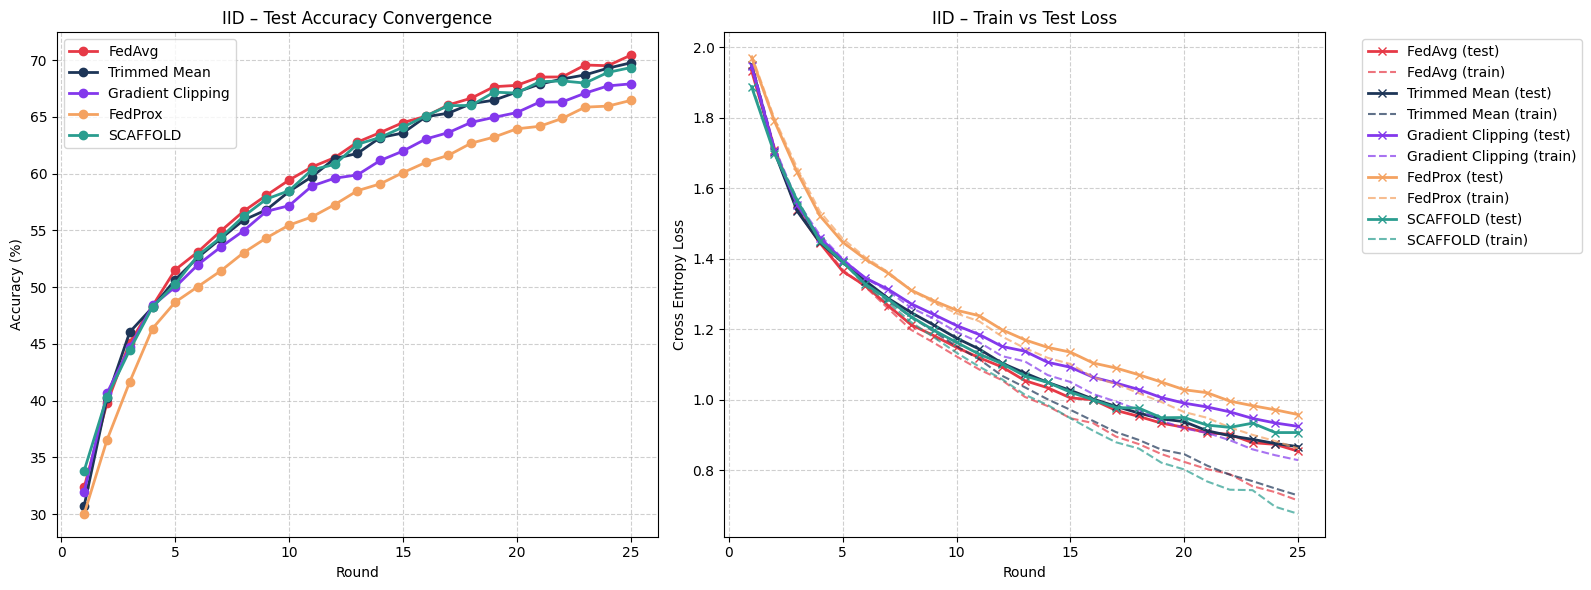

In [ ]:
plt.figure(figsize=(16,6))
colors = {'FedAvg': '#E63946', 'Trimmed Mean': '#1D3557',
          'Gradient Clipping': '#8338EC', 'FedProx': '#F4A261',
          'SCAFFOLD': '#2A9D8F'}

# Test accuracy over rounds
plt.subplot(1,2,1)
for s in strategies:
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_acc'],
             marker='o', color=colors[s], linewidth=2, label=s)
plt.title('IID – Test Accuracy Convergence')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Loss curves: test (solid), train (dashed)
plt.subplot(1,2,2)
for s in strategies:
    c = colors[s]
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_loss'],
             marker='x', linestyle='-', linewidth=2, color=c, label=f"{s} (test)")
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['train_loss'],
             linestyle='--', linewidth=1.5, color=c, alpha=0.7, label=f"{s} (train)")
plt.title('IID – Train vs Test Loss')
plt.xlabel('Round')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


# Conclusion – IID Federated Learning on CIFAR‑10

## Key Results

| Strategy          | Final Test Accuracy (25 rounds)|
|-------------------|--------------------------------|
| FedAvg            | 70.42%                         |
| Trimmed Mean      | 69.75%                         |
| Gradient Clipping | 67.90%                         |
| FedProx           | 66.44%                         |
| SCAFFOLD          | 69.33%                         |

## Observations

### 1. FedAvg performs best in IID conditions
With homogeneous data, the simple weighted average of client models is optimal. FedAvg reaches **70.4%** – the highest among all strategies.

### 2. Trimmed Mean and SCAFFOLD are close seconds
- **Trimmed Mean** (69.8%) lags by only 0.7%, showing that discarding 10% of extreme values does not harm IID convergence.
- **SCAFFOLD** (69.3%) works well when data is IID, but its control variates are not needed – they add complexity without benefit.

### 3. Gradient Clipping with fixed threshold is slightly worse but stable
The 80th‑percentile threshold (≈14.44) clips some updates, slowing convergence. Final accuracy (67.9%) is 2.5% below FedAvg. However, the method never diverges and is easy to implement.

### 4. FedProx underperforms in IID
The proximal penalty (`μ = 0.1`) forces local models to stay close to the global model, which is unnecessary when clients have similar data. This reduces exploration and hurts final accuracy (66.4%).

## What this means for non‑IID experiments

The IID baseline shows that **FedAvg is the gold standard when data is balanced**. Any degradation in non‑IID settings will be due to statistical heterogeneity. The relatively small gap between FedAvg and Gradient Clipping (2.5%) suggests that clipping does not catastrophically harm performance – a good sign for its use under skew, where it may actually help.

## Practical takeaway

In IID federated learning, **stick with FedAvg** – it is simple, fast, and optimal. Only consider robust alternatives when you have evidence of client data skew.